# Hospital Readmission Risk Analysis

This notebook analyzes hospital readmission patterns using the Diabetes 130-US hospitals dataset. The goal is to identify factors associated with hospital readmissions and explore whether patient characteristics and treatment variables influence readmission risk.

In [1]:
#install the libraries 
!pip install pandas numpy seaborn matplotlib

In [2]:
#import the libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# load the dataset 
df = pd.read_csv("diabetic_data.csv")

The dataset contains 101,766 hospital encounters with 50 features including patient demographics, procedures, medications, and diagnoses.

In [4]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [5]:
#overview of the dataset 
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [6]:
df = df.replace("?", np.nan)

In [7]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

Some columns contain large amounts of missing data or represent identifiers that are not useful for modeling.

In [8]:
#dropping the columns 
df = df.drop(columns=["encounter_id","patient_nbr", "weight","payer_code","medical_specialty"])

In [9]:
#converting the response variable to binary
df["readmitted"] = df["readmitted"].replace({
    ">30":0,
    "<30":1,
    "NO":0
})

/var/folders/mv/m_x9c2c514gbf1p4df0xwxdm0000gn/T/ipykernel_15886/632273965.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["readmitted"] = df["readmitted"].replace({


Text(0.5, 1.0, 'Distribution of Hospital Stay Length')

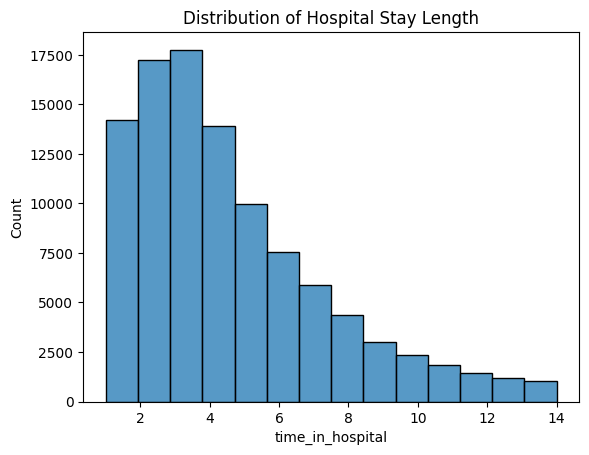

In [10]:
#distribution of hospital stay 
sns.histplot(df["time_in_hospital"], bins=14)
plt.title("Distribution of Hospital Stay Length")

## Exploratory Data Analysis

<Axes: xlabel='count', ylabel='age'>

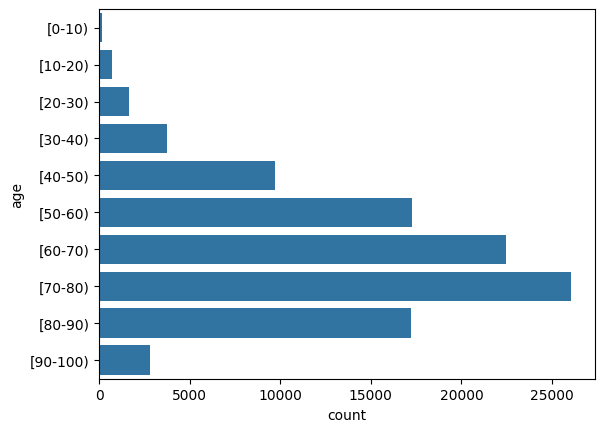

In [11]:
#age distribution 
sns.countplot(y="age", data=df)

Text(0, 0.5, 'Proportion')

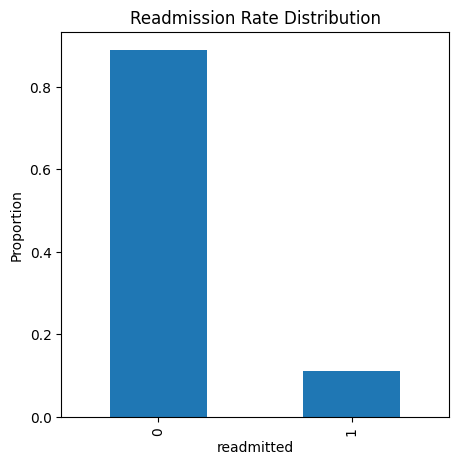

In [12]:
#Readmission percentage plot 
readmission_rate = df["readmitted"].value_counts(normalize=True)

plt.figure(figsize=(5,5))
readmission_rate.plot(kind="bar")
plt.title("Readmission Rate Distribution")
plt.ylabel("Proportion")

Text(0.5, 1.0, 'Distribution of Diagnoses per Patient')

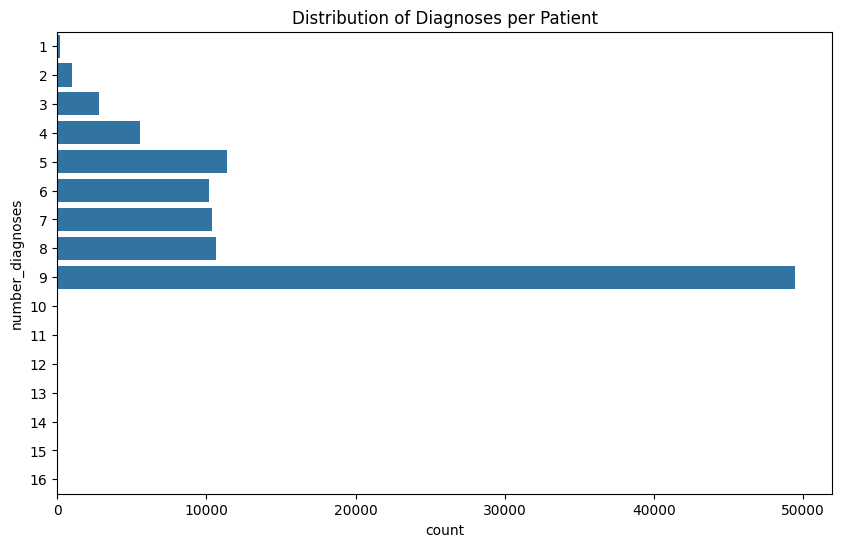

In [13]:
#Diagnosis distribution 
plt.figure(figsize=(10,6))
sns.countplot(y="number_diagnoses", data=df)
plt.title("Distribution of Diagnoses per Patient")

Text(0.5, 1.0, 'Prior Inpatient Visits Distribution')

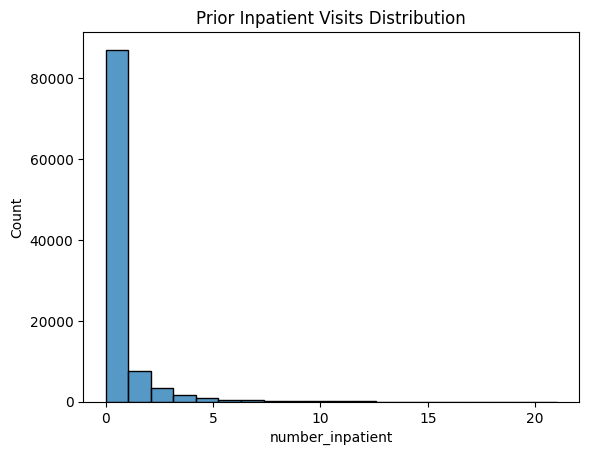

In [14]:
#inpatient visit distribution
sns.histplot(df["number_inpatient"], bins=20)
plt.title("Prior Inpatient Visits Distribution")

<Axes: xlabel='readmitted', ylabel='time_in_hospital'>

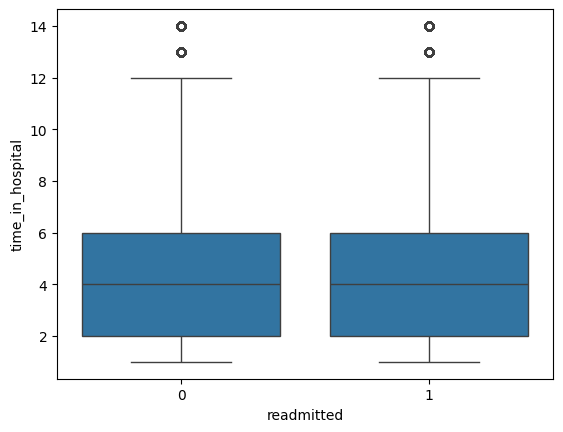

In [15]:
#Hospital stay vs readmission
sns.boxplot(x="readmitted", y="time_in_hospital", data=df)

Most patients were not readmitted within 30 days. This class imbalance may influence predictive modeling performance.

<Axes: xlabel='readmitted', ylabel='num_medications'>

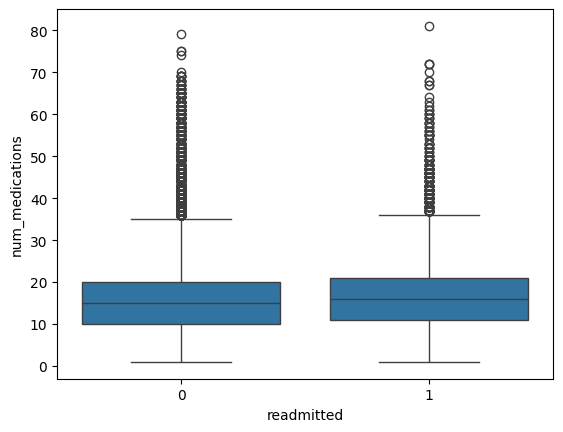

In [16]:
#Number of medications vs readmission
sns.boxplot(x="readmitted", y="num_medications", data=df)

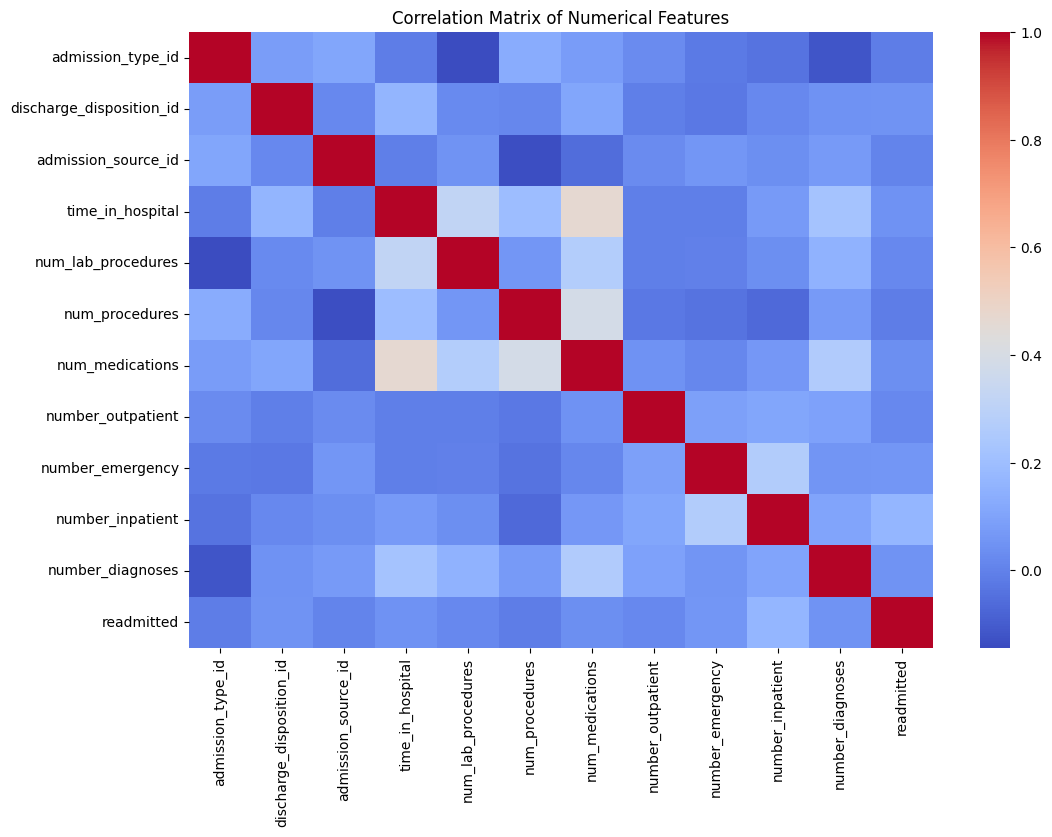

In [17]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

## Predictive Modelling 

In [18]:
#ML MODELS(logistic regression and random forest)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


In [19]:
#preparing the features 
X = df[[
"time_in_hospital",
"num_lab_procedures",
"num_medications",
"number_outpatient",
"number_emergency",
"number_inpatient",
"number_diagnoses"
]]

y = df["readmitted"]

In [20]:
#training the model using logistic regression 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.8873440110052078


Text(0.5, 1.0, 'Confusion Matrix - Logistic Regression')

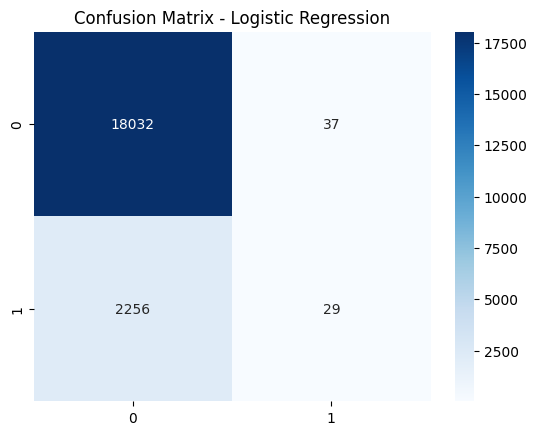

In [21]:
#confusion matrix for logistic regression 
cm_lr = confusion_matrix(y_test, preds)

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")

In [22]:
#using random forest


rf = RandomForestClassifier()
rf.fit(X_train,y_train)

importances = rf.feature_importances_

importances

array([0.11381028, 0.42777744, 0.26780896, 0.04253662, 0.02624685,
       0.05594093, 0.06587892])

In [23]:
# accuracy for random forest 
rf_preds = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test,rf_preds))

Random Forest Accuracy: 0.8669057679080279


Text(0.5, 1.0, 'Confusion Matrix - Random Forest')

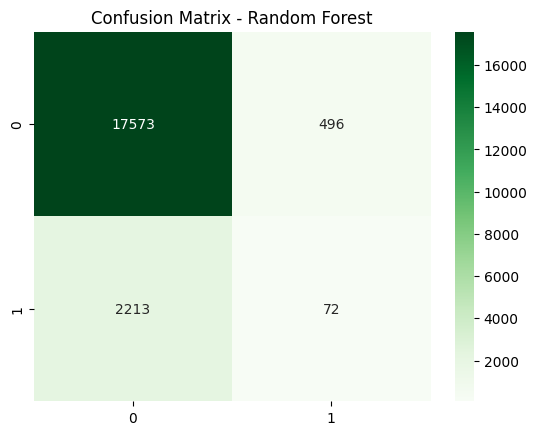

In [24]:
#confusion matrix for random forest 
cm_rf = confusion_matrix(y_test, rf_preds)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")



## Key Insights

• Patients with longer hospital stays tend to have a higher probability of readmission.

• Patients receiving a larger number of medications show increased readmission risk, suggesting higher clinical complexity.

• Prior inpatient visits appear to be a strong predictor of future hospital readmissions.

• The predictive models show moderate performance, indicating that additional features such as diagnosis codes or treatment patterns may further improve prediction accuracy.